<a href="https://colab.research.google.com/github/samantakoushik/WebLaTex/blob/main/fault_1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Excel
df = pd.read_excel('/content/port3.xlsx')
print(df.columns)

time = df['Time'].values
v_normal = df['Port_3_n'].values

# ISC cases
isc_cases = {
    "ISC_3": df['Port_3_3'].values,
    "ISC_10": df['Port_3_10'].values,
    "ISC_20": df['Port_3_20'].values,
    "ISC_30": df['Port_3_30'].values,
    "ISC_50": df['Port_3_50'].values,
}

Index(['Time', 'Port_3_n', 'Port_3_3', 'Port_3_10', 'Port_3_20', 'Port_3_30',
       'Port_3_50'],
      dtype='object')


In [34]:
def recursive_corr(x, y, window):

    N = len(x)
    corr = np.zeros(N)*np.nan

    sum_xy = 0
    sum_x2 = 0
    sum_y2 = 0

    # Initial window
    for i in range(window):
        sum_xy += x[i]*y[i]
        sum_x2 += x[i]**2
        sum_y2 += y[i]**2

    corr[window] = sum_xy/np.sqrt(sum_x2*sum_y2)

    # Recursive update
    for i in range(window+1, N):

        sum_xy += x[i]*y[i] - x[i-window]*y[i-window]
        sum_x2 += x[i]**2 - x[i-window]**2
        sum_y2 += y[i]**2 - y[i-window]**2

        denom = np.sqrt(sum_x2*sum_y2)
        corr[i] = sum_xy/denom if denom != 0 else 0

    return corr

In [35]:
def recursive_mse(x, y, window):

    N = len(x)
    mse = np.zeros(N)*np.nan

    sum_err = 0

    for i in range(window):
        sum_err += (x[i]-y[i])**2

    mse[window] = sum_err/window

    for i in range(window+1, N):
        sum_err += (x[i]-y[i])**2 - (x[i-window]-y[i-window])**2
        mse[i] = sum_err/window

    return mse

In [36]:
window = 1

corr_res = {}
mse_res = {}

for key, isc in isc_cases.items():
    corr_res[key] = recursive_corr(v_normal, isc, window)
    mse_res[key] = recursive_mse(v_normal, isc, window)

**added by ks**

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

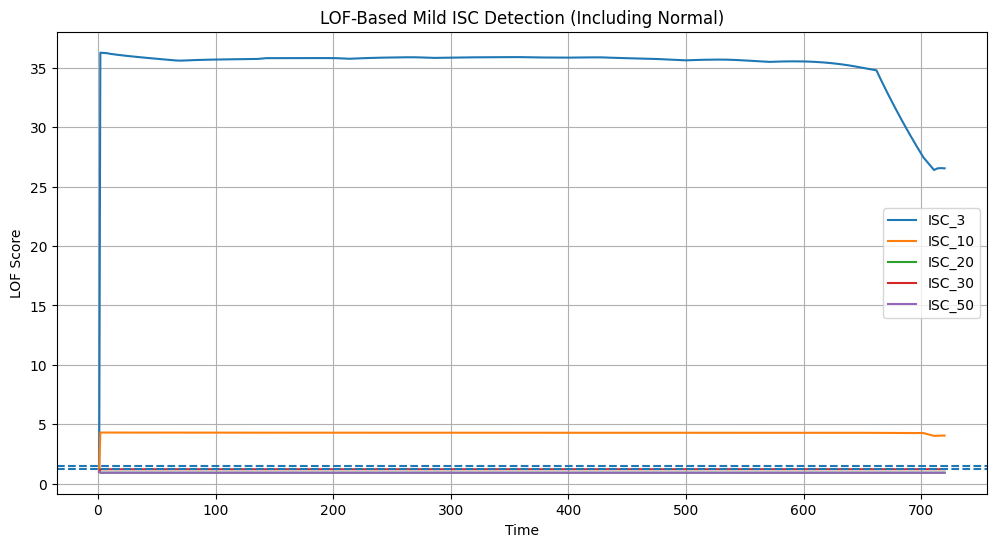

LOF results exported as LOF_results.csv


In [37]:
# ==========================================
# FULL LOF [1d] IMPLEMENTATION (WITH NORMAL)
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

# Convert dictionary to matrix
keys = list(mse_res.keys())
mse_matrix = np.column_stack([mse_res[key] for key in keys])

# Remove NaNs
valid_idx = ~np.isnan(mse_matrix).any(axis=1)
mse_matrix_clean = mse_matrix[valid_idx]

lof_scores = np.zeros_like(mse_matrix_clean)

k_neighbors = 2

for t in range(mse_matrix_clean.shape[0]):

    X = mse_matrix_clean[t].reshape(-1, 1)

    lof = LocalOutlierFactor(n_neighbors=k_neighbors)
    lof.fit(X)

    lof_scores[t] = -lof.negative_outlier_factor_

# Reconstruct time-aligned results
lof_res = {}

for i, key in enumerate(keys):
    temp = np.zeros(len(time)) * np.nan
    temp[valid_idx] = lof_scores[:, i]
    lof_res[key] = temp
    plt.figure(figsize=(12,6))

for key in lof_res:
    plt.plot(time, lof_res[key], label=key)

plt.axhline(1.2, linestyle='--')
plt.axhline(1.5, linestyle='--')

plt.title("LOF-Based Mild ISC Detection (Including Normal)")
plt.xlabel("Time")
plt.ylabel("LOF Score")
plt.grid()
plt.legend()
plt.show()
lof_df = pd.DataFrame()
lof_df["Time"] = time

for key in lof_res:
    lof_df[key] = lof_res[key]

lof_df.to_csv("LOF_results.csv", index=False)

print("LOF results exported as LOF_results.csv")

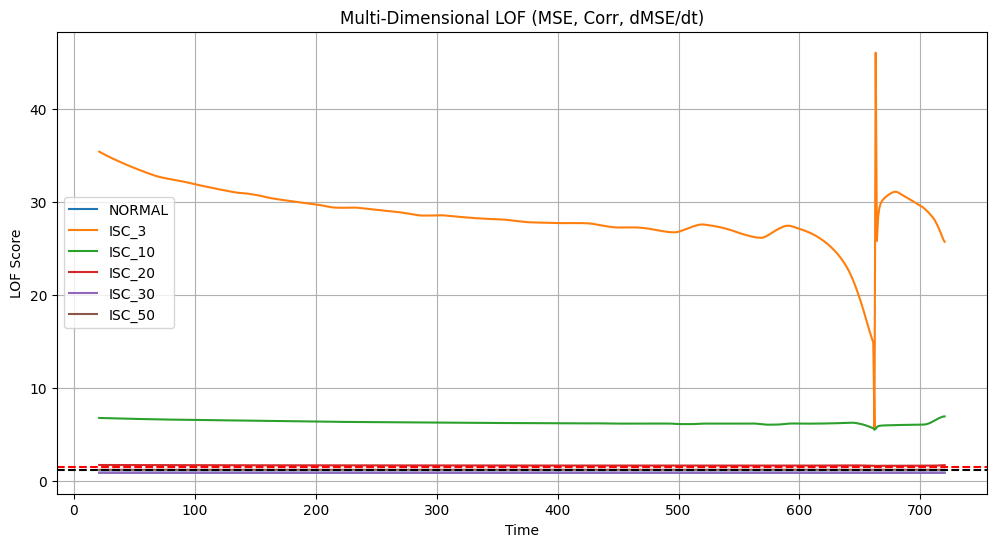

LOF_Multidimensional_results.csv created successfully


In [54]:
# ==========================================================
# COMPLETE MULTI-DIMENSIONAL LOF BASED ISC DETECTION
# Features used: MSE, Correlation, dMSE/dt
# Includes NORMAL case
# Exports CSV
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

# ----------------------------------------------------------
# 1. LOAD DATA (modify path if needed)
# ----------------------------------------------------------
df = pd.read_excel('/content/port3.xlsx')

time = df['Time'].values
v_normal = df['Port_3_n'].values

isc_cases = {
    "NORMAL": v_normal,
    "ISC_3": df['Port_3_3'].values,
    "ISC_10": df['Port_3_10'].values,
    "ISC_20": df['Port_3_20'].values,
    "ISC_30": df['Port_3_30'].values,
    "ISC_50": df['Port_3_50'].values,
}

# ----------------------------------------------------------
# 2. DEFINE RECURSIVE FUNCTIONS
# ----------------------------------------------------------

def recursive_corr(x, y, window):
    N = len(x)
    corr = np.zeros(N) * np.nan
    sum_xy = sum_x2 = sum_y2 = 0

    for i in range(window):
        sum_xy += x[i]*y[i]
        sum_x2 += x[i]**2
        sum_y2 += y[i]**2

    corr[window] = sum_xy/np.sqrt(sum_x2*sum_y2)

    for i in range(window+1, N):
        sum_xy += x[i]*y[i] - x[i-window]*y[i-window]
        sum_x2 += x[i]**2 - x[i-window]**2
        sum_y2 += y[i]**2 - y[i-window]**2
        denom = np.sqrt(sum_x2*sum_y2)
        corr[i] = sum_xy/denom if denom != 0 else 0

    return corr


def recursive_mse(x, y, window):
    N = len(x)
    mse = np.zeros(N) * np.nan
    sum_err = 0

    for i in range(window):
        sum_err += (x[i]-y[i])**2

    mse[window] = sum_err/window

    for i in range(window+1, N):
        sum_err += (x[i]-y[i])**2 - (x[i-window]-y[i-window])**2
        mse[i] = sum_err/window

    return mse


# ----------------------------------------------------------
# 3. COMPUTE MSE & CORRELATION
# ----------------------------------------------------------
window = 20   # better than 1 for mild ISC detection

mse_res = {}
corr_res = {}

for key, signal in isc_cases.items():
    mse_res[key] = recursive_mse(v_normal, signal, window)
    corr_res[key] = recursive_corr(v_normal, signal, window)

# ----------------------------------------------------------
# 4. COMPUTE dMSE/dt
# ----------------------------------------------------------
dmse_res = {}
dt = np.mean(np.diff(time))

for key in mse_res:
    dmse_res[key] = np.gradient(mse_res[key], dt)

# ----------------------------------------------------------
# 5. BUILD MULTI-DIMENSIONAL FEATURE MATRIX
# ----------------------------------------------------------
keys = list(mse_res.keys())
feature_tensor = []

for key in keys:
    feature_tensor.append(
        np.vstack((
            mse_res[key],
            corr_res[key],
            dmse_res[key]
        )).T
    )

feature_tensor = np.array(feature_tensor)
# shape = (cases, time, 3 features)

# Remove NaN rows
valid_idx = ~np.isnan(feature_tensor).any(axis=(0,2))
feature_clean = feature_tensor[:, valid_idx, :]

# ----------------------------------------------------------
# 6. MULTI-DIMENSIONAL LOF
# ----------------------------------------------------------
lof_scores = np.zeros((len(keys), feature_clean.shape[1]))

k_neighbors = 2

for t in range(feature_clean.shape[1]):

    X = feature_clean[:, t, :]  # cases × 3 features

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    lof = LocalOutlierFactor(n_neighbors=k_neighbors)
    lof.fit(X_scaled)

    lof_scores[:, t] = -lof.negative_outlier_factor_

# ----------------------------------------------------------
# 7. RECONSTRUCT TIME-ALIGNED RESULTS
# ----------------------------------------------------------
lof_multi = {}

for i, key in enumerate(keys):
    temp = np.zeros(len(time)) * np.nan
    temp[valid_idx] = lof_scores[i]
    lof_multi[key] = temp

# ----------------------------------------------------------
# 8. PLOT LOF RESULTS
# ----------------------------------------------------------
plt.figure(figsize=(12,6))

for key in lof_multi:
    plt.plot(time, lof_multi[key], label=key)

plt.axhline(1.2, linestyle='--', color='black')
plt.axhline(1.5, linestyle='--', color='red')

plt.title("Multi-Dimensional LOF (MSE, Corr, dMSE/dt)")
plt.xlabel("Time")
plt.ylabel("LOF Score")
plt.grid()
plt.legend()
plt.show()

# ----------------------------------------------------------
# 9. EXPORT TO CSV
# ----------------------------------------------------------
lof_df = pd.DataFrame()
lof_df["Time"] = time

for key in lof_multi:
    lof_df[key] = lof_multi[key]

lof_df.to_csv("LOF_Multidimensional_results.csv", index=False)

print("LOF_Multidimensional_results.csv created successfully")

In [38]:
fault_index = {}

for key in mse_res:
    clean = mse_res[key][~np.isnan(mse_res[key])]
    mu = np.mean(clean)
    sigma = np.std(clean)

    fault_index[key] = mu + sigma

print("Fault severity index:")
print(fault_index)

Fault severity index:
{'ISC_3': np.float64(266.6907709703185), 'ISC_10': np.float64(25.146475954239556), 'ISC_20': np.float64(6.331425537889597), 'ISC_30': np.float64(2.8197622452418205), 'ISC_50': np.float64(1.0167073622773573)}


In [39]:
fault_time = {}

for key in corr_res:

    corr_th = np.nanmean(corr_res[key]) - 3*np.nanstd(corr_res[key])
    mse_th  = np.nanmean(mse_res[key]) + 3*np.nanstd(mse_res[key])

    idx = np.where((corr_res[key] < corr_th) | (mse_res[key] > mse_th))[0]

    fault_time[key] = time[idx[0]] if len(idx)>0 else None

print("Detected fault time:")
print(fault_time)

Detected fault time:
{'ISC_3': None, 'ISC_10': None, 'ISC_20': None, 'ISC_30': None, 'ISC_50': None}


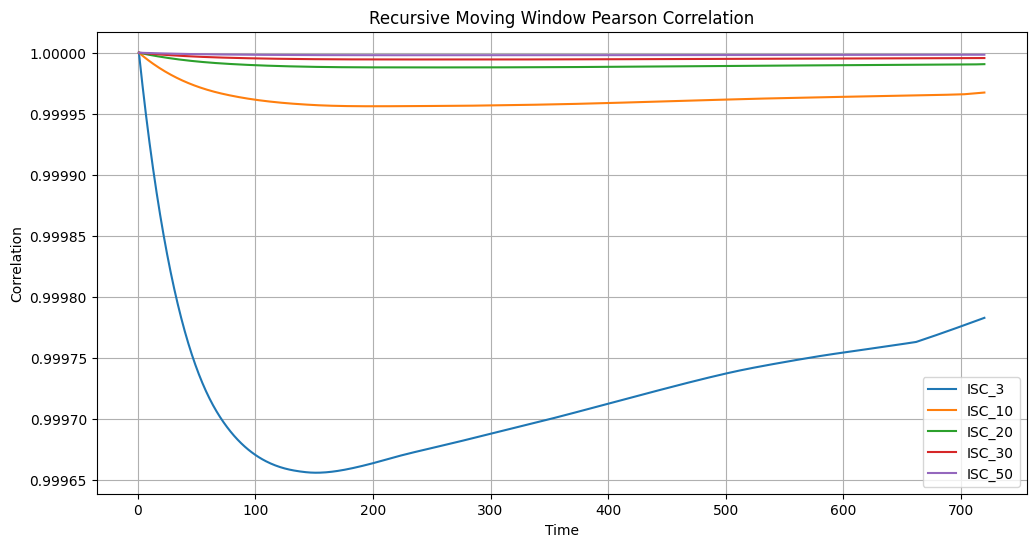

In [40]:
plt.figure(figsize=(12,6))

for key in corr_res:
    plt.plot(time, corr_res[key], label=key)

plt.title("Recursive Moving Window Pearson Correlation")
plt.xlabel("Time")
plt.ylabel("Correlation")
plt.grid()
plt.legend()
plt.show()

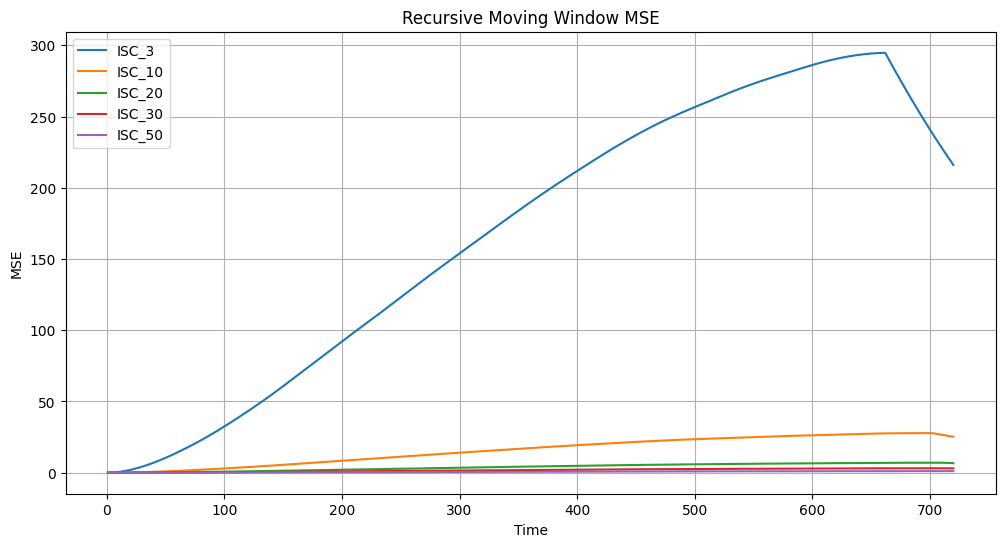

In [41]:
plt.figure(figsize=(12,6))

for key in mse_res:
    plt.plot(time, mse_res[key], label=key)

plt.title("Recursive Moving Window MSE")
plt.xlabel("Time")
plt.ylabel("MSE")
plt.grid()
plt.legend()
plt.show()

In [42]:
corr_df = pd.DataFrame()
corr_df['Time'] = time

for key in corr_res:
    corr_df[key] = corr_res[key]

corr_df.to_csv('Correlation_results.csv', index=False)


mse_df = pd.DataFrame()
mse_df['Time'] = time

for key in mse_res:
    mse_df[key] = mse_res[key]

mse_df.to_csv('MSE_results.csv', index=False)

print("CSV files created")

CSV files created


In [43]:
from google.colab import files
files.download('/content/Correlation_results.csv')
files.download('/content/MSE_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
zscore_res = {}
stats = {}

for key in mse_res:

    mse_clean = mse_res[key][~np.isnan(mse_res[key])]

    mu = np.mean(mse_clean)
    sigma = np.std(mse_clean)

    stats[key] = (mu, sigma)

    z = (mse_res[key] - mu) / sigma
    zscore_res[key] = z

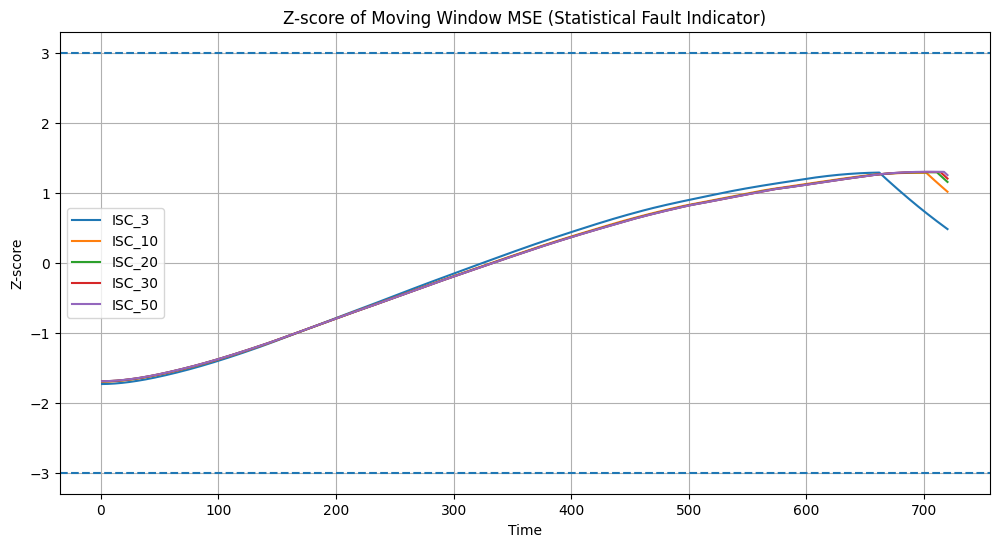

In [45]:
plt.figure(figsize=(12,6))

for key in zscore_res:
    plt.plot(time, zscore_res[key], label=key)

plt.axhline(3, linestyle='--')     # fault threshold
plt.axhline(-3, linestyle='--')

plt.title("Z-score of Moving Window MSE (Statistical Fault Indicator)")
plt.xlabel("Time")
plt.ylabel("Z-score")
plt.grid()
plt.legend()
plt.show()

In [46]:
def moving_stats(signal, window):

    mu = np.zeros(len(signal))*np.nan
    sigma = np.zeros(len(signal))*np.nan

    for i in range(window, len(signal)):
        w = signal[i-window:i]
        mu[i] = np.mean(w)
        sigma[i] = np.std(w)

    return mu, sigma

In [47]:
moving_z = {}

for key in mse_res:

    mu, sigma = moving_stats(mse_res[key], 50)
    moving_z[key] = (mse_res[key] - mu) / sigma

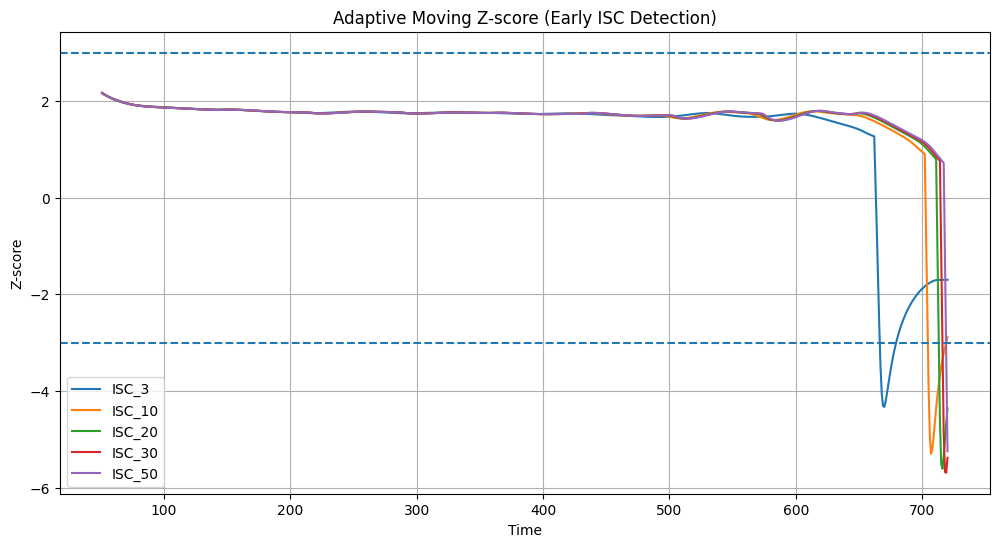

In [48]:
plt.figure(figsize=(12,6))

for key in moving_z:
    plt.plot(time, moving_z[key], label=key)

plt.axhline(3, linestyle='--')
plt.axhline(-3, linestyle='--')

plt.title("Adaptive Moving Z-score (Early ISC Detection)")
plt.xlabel("Time")
plt.ylabel("Z-score")
plt.grid()
plt.legend()
plt.show()

In [49]:
deviation = {}

for key in zscore_res:
    deviation[key] = np.abs(zscore_res[key])

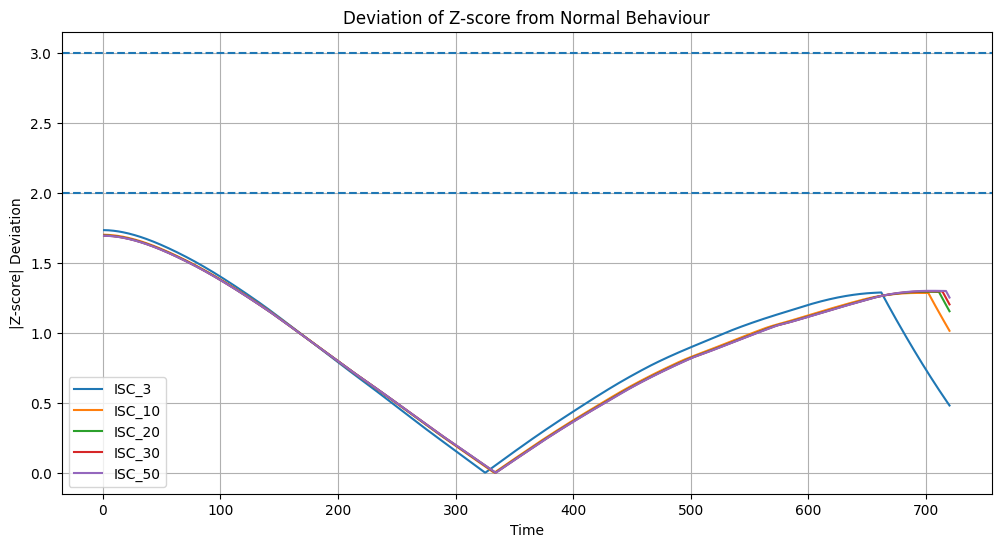

In [50]:
plt.figure(figsize=(12,6))

for key in deviation:
    plt.plot(time, deviation[key], label=key)

plt.axhline(3, linestyle='--')   # strong anomaly
plt.axhline(2, linestyle='--')   # early anomaly

plt.title("Deviation of Z-score from Normal Behaviour")
plt.xlabel("Time")
plt.ylabel("|Z-score| Deviation")
plt.grid()
plt.legend()
plt.show()

In [51]:
sep_metric = {}

for key in deviation:
    clean = deviation[key][~np.isnan(deviation[key])]
    sep_metric[key] = np.mean(clean)

print("Fault separability index:")
print(sep_metric)

Fault separability index:
{'ISC_3': np.float64(0.8873684052472576), 'ISC_10': np.float64(0.8874851729943413), 'ISC_20': np.float64(0.8868335265082954), 'ISC_30': np.float64(0.8866339414233806), 'ISC_50': np.float64(0.88648319893742)}


In [52]:
dev_df = pd.DataFrame()
dev_df['Time'] = time

for key in deviation:
    dev_df[key] = deviation[key]

dev_df.to_csv('Zscore_deviation.csv', index=False)

In [53]:
adaptive_z_df = pd.DataFrame()
adaptive_z_df['Time'] = time

for key in moving_z:
    adaptive_z_df[key] = moving_z[key]

adaptive_z_df.to_csv('Adaptive_Moving_Zscore.csv', index=False)

print("Adaptive moving Z-score CSV created")

Adaptive moving Z-score CSV created


**by ks**

Baseline Mean: 0.5367076267566546
Baseline Std: 0.3047928749221503
Detection Threshold (3σ): 1.4510862515231056

Detection Times:
ISC_3 : 21
ISC_10 : 81
ISC_20 : 200
ISC_50 : None


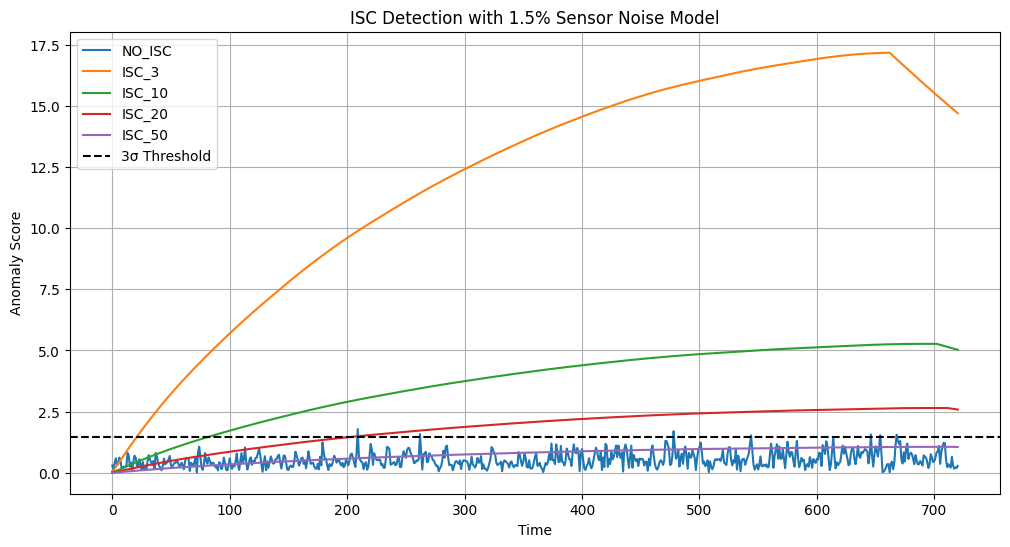


CSV file created: Temperature_ISC_with_noise_detection.csv


In [63]:
# ==========================================================
# TEMPERATURE-BASED ISC DETECTION
# WITH REALISTIC SENSOR NOISE (±1.5%)
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load Data
# -----------------------------
df = pd.read_excel('/content/port3.xlsx')

time = df['Time'].values
T_normal = df['Port_3_n'].values

isc_cases = {
    "ISC_3": df['Port_3_3'].values,
    "ISC_10": df['Port_3_10'].values,
    "ISC_20": df['Port_3_20'].values,
    "ISC_50": df['Port_3_50'].values,
}

dt = np.mean(np.diff(time))

# -----------------------------
# Add 1.5% Gaussian Noise to NORMAL
# -----------------------------
noise_level = 0.015
np.random.seed(42)

noise = np.random.normal(0, noise_level, size=len(T_normal))
T_normal_noisy = T_normal * (1 + noise)

# -----------------------------
# Compute Baseline Anomaly Metric
# -----------------------------
delta_baseline = T_normal_noisy - T_normal
dT_baseline = np.gradient(delta_baseline, dt)

baseline_score = np.sqrt(delta_baseline**2 + dT_baseline**2)

# -----------------------------
# Compute ISC Anomaly Scores
# -----------------------------
anomaly_scores = {}
anomaly_scores["NO_ISC"] = baseline_score

for key, T_fault in isc_cases.items():

    delta_T = T_fault - T_normal
    dT_dt = np.gradient(delta_T, dt)

    score = np.sqrt(delta_T**2 + dT_dt**2)
    anomaly_scores[key] = score

# -----------------------------
# Compute 3-Sigma Threshold
# -----------------------------
mu_baseline = np.mean(baseline_score)
sigma_baseline = np.std(baseline_score)

threshold = mu_baseline + 3 * sigma_baseline

print("Baseline Mean:", mu_baseline)
print("Baseline Std:", sigma_baseline)
print("Detection Threshold (3σ):", threshold)

# -----------------------------
# Automatic Detection Time
# -----------------------------
detection_time = {}

for key in isc_cases:

    idx = np.where(anomaly_scores[key] > threshold)[0]

    if len(idx) > 0:
        detection_time[key] = time[idx[0]]
    else:
        detection_time[key] = None

print("\nDetection Times:")
for k,v in detection_time.items():
    print(k, ":", v)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12,6))

for key in anomaly_scores:
    plt.plot(time, anomaly_scores[key], label=key)

plt.axhline(threshold, color='black', linestyle='--', label='3σ Threshold')

plt.title("ISC Detection with 1.5% Sensor Noise Model")
plt.xlabel("Time")
plt.ylabel("Anomaly Score")
plt.grid()
plt.legend()
plt.show()

# -----------------------------
# Export CSV
# -----------------------------
out_df = pd.DataFrame()
out_df["Time"] = time

for key in anomaly_scores:
    out_df[key] = anomaly_scores[key]

out_df["Threshold"] = threshold

out_df.to_csv("Temperature_ISC_with_noise_detection.csv", index=False)

print("\nCSV file created: Temperature_ISC_with_noise_detection.csv")

========== K-Type Thermocouple Case ==========
Baseline Mean: 0.2689714088334975
Baseline Std: 0.1478126549469639
Detection Threshold (3σ): 0.7124093736743893

Detection Times:
ISC_3 : 10
ISC_10 : 35
ISC_20 : 79
ISC_50 : 275


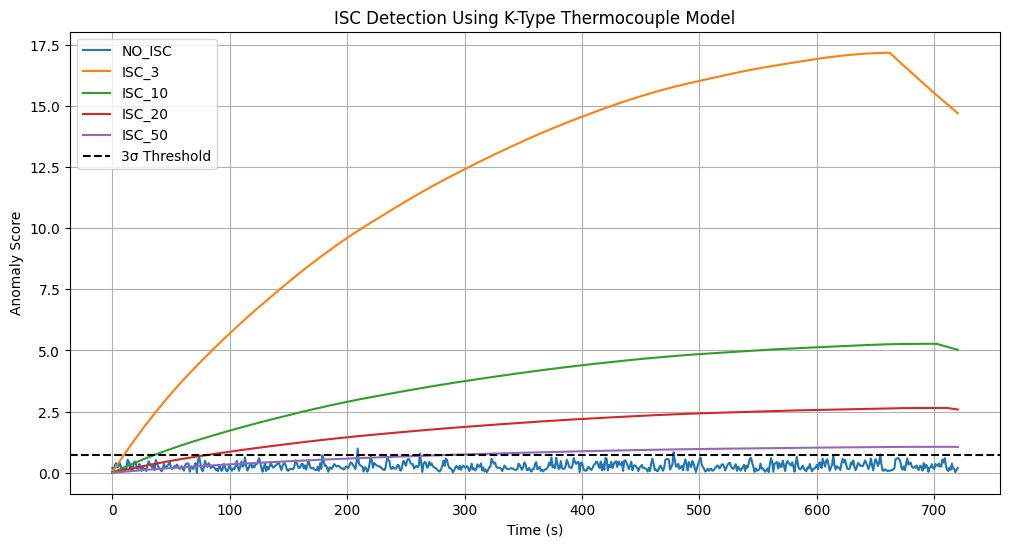


CSV file created: ISC_Detection_KType_Thermocouple.csv


In [64]:
# ==========================================================
# ISC DETECTION USING K-TYPE THERMOCOUPLE MODEL
# Additive noise + Drift + 3σ Detection
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. LOAD DATA
# ----------------------------------------------------------
df = pd.read_excel('/content/port3.xlsx')

time = df['Time'].values
T_normal = df['Port_3_n'].values

isc_cases = {
    "ISC_3": df['Port_3_3'].values,
    "ISC_10": df['Port_3_10'].values,
    "ISC_20": df['Port_3_20'].values,
    "ISC_50": df['Port_3_50'].values,
}

dt = np.mean(np.diff(time))

# ----------------------------------------------------------
# 2. K-TYPE THERMOCOUPLE NOISE MODEL
# ----------------------------------------------------------

np.random.seed(42)

# Additive random noise (0.25°C standard deviation)
add_noise = np.random.normal(0, 0.25, size=len(T_normal))

# Slow drift (0.1°C over experiment duration)
drift = np.linspace(0, 0.1, len(T_normal))

# Measured normal temperature
T_normal_measured = T_normal + add_noise + drift

# ----------------------------------------------------------
# 3. BASELINE ANOMALY METRIC
# ----------------------------------------------------------

delta_baseline = T_normal_measured - T_normal
dT_baseline = np.gradient(delta_baseline, dt)

baseline_score = np.sqrt(delta_baseline**2 + dT_baseline**2)

# ----------------------------------------------------------
# 4. ISC ANOMALY SCORES
# ----------------------------------------------------------

anomaly_scores = {}
anomaly_scores["NO_ISC"] = baseline_score

for key, T_fault in isc_cases.items():

    delta_T = T_fault - T_normal
    dT_dt = np.gradient(delta_T, dt)

    score = np.sqrt(delta_T**2 + dT_dt**2)

    anomaly_scores[key] = score

# ----------------------------------------------------------
# 5. 3-SIGMA THRESHOLD
# ----------------------------------------------------------

mu_baseline = np.mean(baseline_score)
sigma_baseline = np.std(baseline_score)

threshold = mu_baseline + 3 * sigma_baseline

print("========== K-Type Thermocouple Case ==========")
print("Baseline Mean:", mu_baseline)
print("Baseline Std:", sigma_baseline)
print("Detection Threshold (3σ):", threshold)

# ----------------------------------------------------------
# 6. AUTOMATIC DETECTION TIME
# ----------------------------------------------------------

detection_time = {}

for key in isc_cases:

    idx = np.where(anomaly_scores[key] > threshold)[0]

    if len(idx) > 0:
        detection_time[key] = time[idx[0]]
    else:
        detection_time[key] = None

print("\nDetection Times:")
for k, v in detection_time.items():
    print(k, ":", v)

# ----------------------------------------------------------
# 7. PLOT RESULTS
# ----------------------------------------------------------

plt.figure(figsize=(12,6))

for key in anomaly_scores:
    plt.plot(time, anomaly_scores[key], label=key)

plt.axhline(threshold, color='black', linestyle='--', label='3σ Threshold')

plt.title("ISC Detection Using K-Type Thermocouple Model")
plt.xlabel("Time (s)")
plt.ylabel("Anomaly Score")
plt.grid()
plt.legend()
plt.show()

# ----------------------------------------------------------
# 8. EXPORT CSV
# ----------------------------------------------------------

out_df = pd.DataFrame()
out_df["Time"] = time

for key in anomaly_scores:
    out_df[key] = anomaly_scores[key]

out_df["Threshold"] = threshold

out_df.to_csv("ISC_Detection_KType_Thermocouple.csv", index=False)

print("\nCSV file created: ISC_Detection_KType_Thermocouple.csv")